shape: (1, 19)
┌───────┬─────┬─────┬─────────┬───┬────────────┬───────────┬───────────┬────────────┐
│ Fecha ┆ Luz ┆ Gas ┆ Energia ┆ … ┆ Luz_lag_30 ┆ Gas_lag_1 ┆ Gas_lag_7 ┆ Gas_lag_30 │
│ ---   ┆ --- ┆ --- ┆ ---     ┆   ┆ ---        ┆ ---       ┆ ---       ┆ ---        │
│ u32   ┆ u32 ┆ u32 ┆ u32     ┆   ┆ u32        ┆ u32       ┆ u32       ┆ u32        │
╞═══════╪═════╪═════╪═════════╪═══╪════════════╪═══════════╪═══════════╪════════════╡
│ 0     ┆ 0   ┆ 0   ┆ 0       ┆ … ┆ 30         ┆ 1         ┆ 7         ┆ 30         │
└───────┴─────┴─────┴─────────┴───┴────────────┴───────────┴───────────┴────────────┘
[Date, Float64, Float64, Float64, Float64, Float64, Float64, Int64, Int64, Int64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64]
Train: 1800
Test: 731

Rango train:
2019-01-27 2023-12-31

Rango test:
2024-01-01 2025-12-31
MAE: 0.009711944181531802
RMSE: 0.012524479386124193
R2: 0.8113313691071762


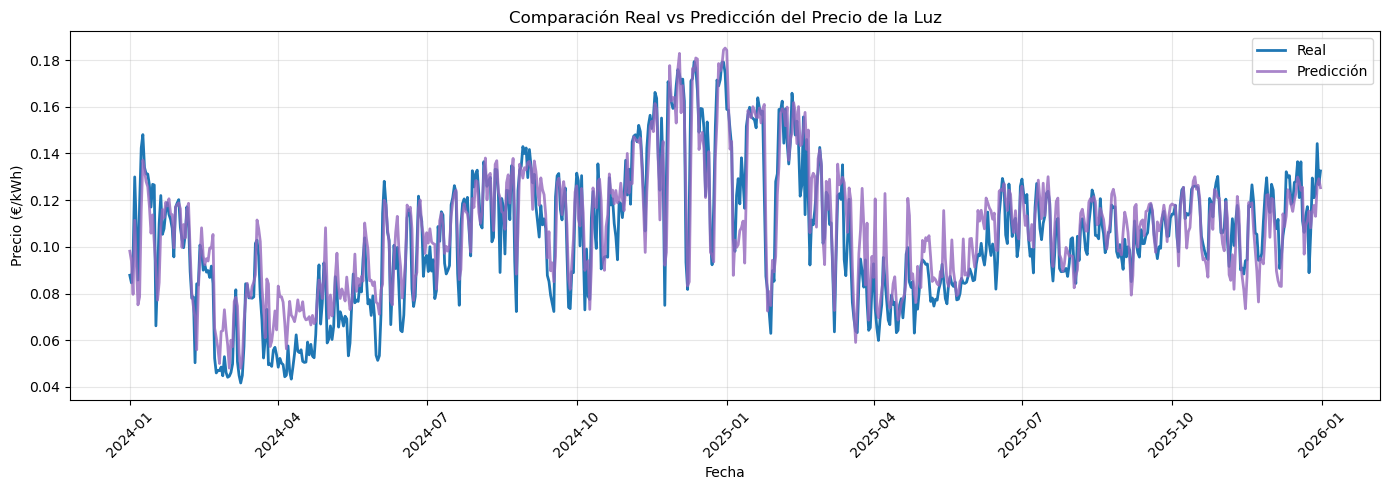

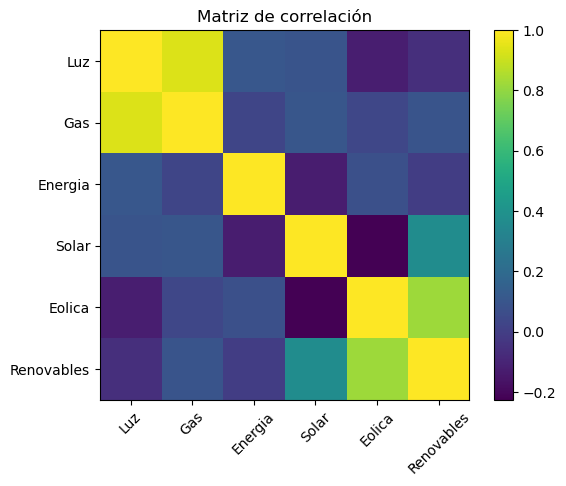

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import timedelta
import random

ruta = "/Users/macbook/ProyectosLocales/PrecioLuz/datos/datos_limpios.csv"

df = pl.read_csv(ruta)

# lags
for lag in [1,2,3,7,14,30]:
    df = df.with_columns(pl.col("Luz").shift(lag).alias(f"Luz_lag_{lag}"))

for lag in [1,7,30]:
    df = df.with_columns(pl.col("Gas").shift(lag).alias(f"Gas_lag_{lag}"))

print(df.null_count())

df = df.drop_nulls()

# fecha
df = df.with_columns(
    pl.col("Fecha").cast(pl.Utf8).str.slice(0,10).str.strptime(pl.Date, "%Y-%m-%d")
)

print(df.dtypes)

# split
train = df.filter(pl.col("Fecha") < pl.date(2024,1,1))
test = df.filter(pl.col("Fecha") >= pl.date(2024,1,1))

print("Train:", train.height)
print("Test:", test.height)

print("\nRango train:")
print(train["Fecha"].min(), train["Fecha"].max())

print("\nRango test:")
print(test["Fecha"].min(), test["Fecha"].max())

# target
y_train = train["Luz"]
y_test = test["Luz"]

# features
X_train = train.drop(["Fecha", "Luz"])
X_test = test.drop(["Fecha", "Luz"])

# modelo
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train.to_numpy(), y_train.to_numpy().ravel())

pred = model.predict(X_test.to_numpy())

# métricas
print("MAE:", mean_absolute_error(y_test.to_numpy(), pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test.to_numpy(), pred)))
print("R2:", r2_score(y_test.to_numpy(), pred))

# gráfico bonito (TUYO)
fechas = test["Fecha"].to_list()
y_real = y_test.to_list()
y_pred = pred.tolist()

plt.figure(figsize=(14,5))

plt.plot(fechas, y_real, label="Real", color="#1f77b4", linewidth=2)
plt.plot(fechas, y_pred, label="Predicción", color="#9467bd", linewidth=2, alpha=0.8)

plt.title("Comparación Real vs Predicción del Precio de la Luz")
plt.xlabel("Fecha")
plt.ylabel("Precio (€/kWh)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# correlación (TUYA)
cols = ["Luz", "Gas", "Energia", "Solar", "Eolica", "Renovables"]

data = df.select(cols).to_numpy()
corr = np.corrcoef(data, rowvar=False)

plt.figure()
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)

plt.title("Matriz de correlación")
plt.show()

Progreso: 0%
Progreso: 18%
Progreso: 36%
Progreso: 54%
Progreso: 73%
Progreso: 91%


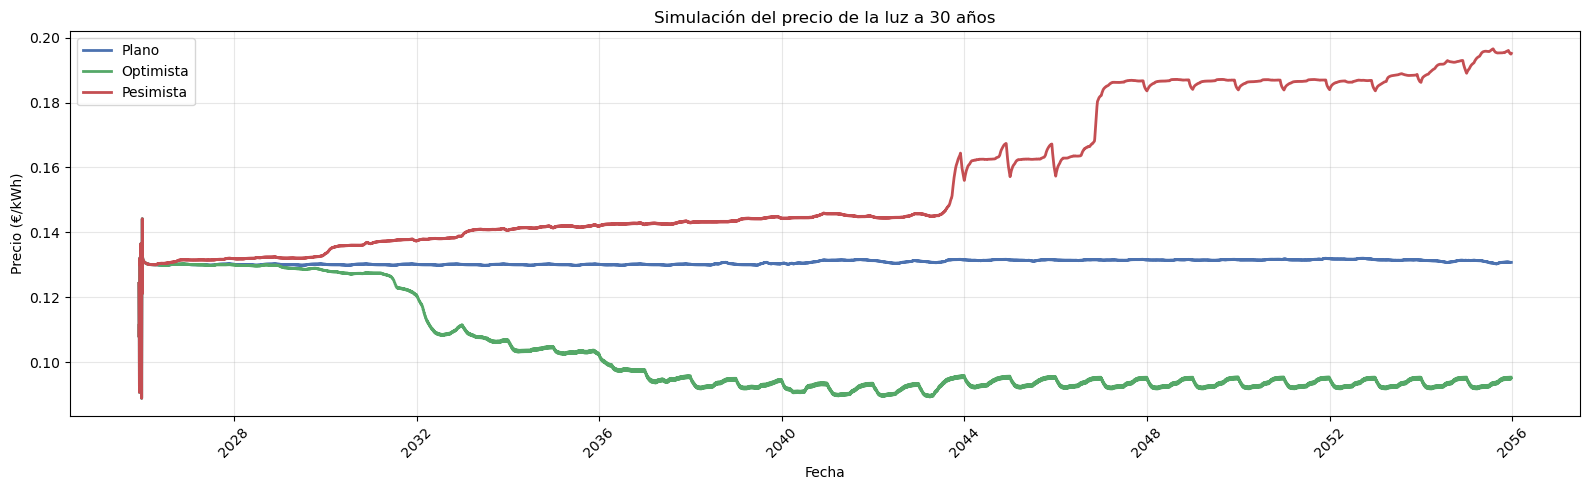

In [2]:
columnas_modelo = X_train.columns
df_futuro = df.sort("Fecha").tail(30)

def simular(df_base, modelo, columnas_modelo, dias, escenario):

    df_sim = df_base.sort("Fecha").clone()
    media_global = df_base["Luz"].mean()

    for i in range(dias):

        # progreso limpio (solo en plano)
        if escenario == "plano" and i % 2000 == 0:
            print(f"Progreso: {int(i/dias*100)}%")

        nueva_fecha = df_sim["Fecha"][-1] + timedelta(days=1)

        # lags
        lags = {f"Luz_lag_{lag}": df_sim["Luz"][-lag] for lag in [1,2,3,7,14,30]}
        gas_lags = {f"Gas_lag_{lag}": df_sim["Gas"][-lag] for lag in [1,7,30]}

        gas = df_sim["Gas"][-1]
        renovables = df_sim["Renovables"][-1]

        if escenario == "plano":
            gas = gas * (1 + random.uniform(-0.001, 0.001))

        elif escenario == "verde":
            gas = gas * (1 - 0.02/365)
            renovables = renovables * (1 + 0.05/365)

        elif escenario == "pesimista":
            gas = gas * (1 + 0.03/365)
            renovables = renovables * (1 + 0.01/365)

        nueva_fila = {
            "Fecha": nueva_fecha,
            "Gas": gas,
            "Renovables": renovables,
            "Energia": df_sim["Energia"][-1],
            "Solar": df_sim["Solar"][-1],
            "Eolica": df_sim["Eolica"][-1],
            "mes": nueva_fecha.month,
            "dia": nueva_fecha.weekday(),
            "anio": nueva_fecha.year
        }

        nueva_fila.update(lags)
        nueva_fila.update(gas_lags)

        fila_df = pl.DataFrame([nueva_fila])

        X = fila_df.select(columnas_modelo)
        pred = modelo.predict(X.to_numpy())[0]

        # suavizado
        pred = 0.95 * df_sim["Luz"][-1] + 0.05 * pred

        # control cambios
        cambio_max = 0.005
        pred = max(df_sim["Luz"][-1] - cambio_max,
                   min(pred, df_sim["Luz"][-1] + cambio_max))

        if abs(pred - df_sim["Luz"][-1]) > 0.02:
            pred = df_sim["Luz"][-1]

        # límites
        media_local = df_sim["Luz"].mean()
        pred = max(media_local*0.5, min(pred, media_local*2))
        pred = max(media_global*0.6, min(pred, media_global*1.8))

        fila_df = fila_df.with_columns(pl.lit(pred).alias("Luz"))

        for col in df_sim.columns:
            if col not in fila_df.columns:
                fila_df = fila_df.with_columns(pl.lit(None).alias(col))

        fila_df = fila_df.select(df_sim.columns)

        df_sim = df_sim.vstack(fila_df)

    return df_sim

# simulaciones
df_plano = simular(df_futuro, model, columnas_modelo, 365*30, "plano")
df_verde = simular(df_futuro, model, columnas_modelo, 365*30, "verde")
df_pesimista = simular(df_futuro, model, columnas_modelo, 365*30, "pesimista")

# grafico
plt.figure(figsize=(16,5))

fechas = df_plano["Fecha"].to_list()

plt.plot(fechas, df_plano["Luz"].to_list(), label="Plano", color="#4c72b0", linewidth=2)
plt.plot(fechas, df_verde["Luz"].to_list(), label="Optimista", color="#55a868", linewidth=2)
plt.plot(fechas, df_pesimista["Luz"].to_list(), label="Pesimista", color="#c44e52", linewidth=2)

plt.title("Simulación del precio de la luz a 30 años")
plt.xlabel("Fecha")
plt.ylabel("Precio (€/kWh)")

plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# guardar
df.write_csv("/Users/macbook/ProyectosLocales/PrecioLuz/datos/datos_modelo.csv")

In [3]:
# función para convertir cada simulación en tabla mensual
def preparar_tabla(df, nombre_escenario):
    return (
        df
        .group_by(["anio", "mes"])
        .agg(pl.col("Luz").mean().alias("precio_luz"))
        .with_columns(pl.lit(nombre_escenario).alias("escenario"))
    )

# crear tablas
tabla_plano = preparar_tabla(df_plano, "plano")
tabla_verde = preparar_tabla(df_verde, "verde")
tabla_pesimista = preparar_tabla(df_pesimista, "pesimista")

# unir todo
tabla_escenarios = pl.concat([
    tabla_plano,
    tabla_verde,
    tabla_pesimista
]).sort(["escenario", "anio", "mes"])

print(tabla_escenarios)

shape: (1_083, 4)
┌──────┬─────┬────────────┬───────────┐
│ anio ┆ mes ┆ precio_luz ┆ escenario │
│ ---  ┆ --- ┆ ---        ┆ ---       │
│ i64  ┆ i64 ┆ f64        ┆ str       │
╞══════╪═════╪════════════╪═══════════╡
│ 2025 ┆ 12  ┆ 0.118475   ┆ pesimista │
│ 2026 ┆ 1   ┆ 0.130948   ┆ pesimista │
│ 2026 ┆ 2   ┆ 0.130238   ┆ pesimista │
│ 2026 ┆ 3   ┆ 0.130084   ┆ pesimista │
│ 2026 ┆ 4   ┆ 0.130108   ┆ pesimista │
│ …    ┆ …   ┆ …          ┆ …         │
│ 2055 ┆ 8   ┆ 0.093591   ┆ verde     │
│ 2055 ┆ 9   ┆ 0.094189   ┆ verde     │
│ 2055 ┆ 10  ┆ 0.094854   ┆ verde     │
│ 2055 ┆ 11  ┆ 0.09508    ┆ verde     │
│ 2055 ┆ 12  ┆ 0.095174   ┆ verde     │
└──────┴─────┴────────────┴───────────┘


In [4]:
tabla_escenarios.write_csv(
    "/Users/macbook/ProyectosLocales/PrecioLuz/datos/prediccion_30_anios.csv"
)